<a id="top"></a>
# Load and plot the radio dynamic spectra from PSP, SolO, STA, and Wind spacecraft

1.  [Imports](#imports)
2.  [Utility Functions](#utility_functions)
3.  [Load PSP](#load_psp)
4.  [Load SolO](#load_solo)
5.  [Load STA](#load_sta)
6.  [Load Wind](#load_wind)
7.  [Plotting](#plot)

<a id="imports"></a>
## Imports

In [196]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import glob
import requests
import datetime
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.dates import DateFormatter
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter
from spacepy import pycdf
from astropy import units as u
from astropy.visualization import ImageNormalize, SqrtStretch, PercentileInterval
import sunpy.map
from sunpy import timeseries as ts
from sunpy.net import Fido, attrs as a
from scipy.ndimage import gaussian_filter
from WIND_Software_L2_Radio import read_l2_hres
myFmt_time = DateFormatter('%H:%M')

# Construct the full path to the scripts directory
script_path = os.path.abspath('../scripts')
# Add the scripts directory to sys.path
if script_path not in sys.path:
    # sys.path.append(script_path)
    sys.path.insert(0, script_path)

mpl.rcParams['date.epoch'] = '1970-01-01T00:00:00'
try: mdates.set_epoch('1970-01-01T00:00:00')
except: pass

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

basedir = '/home/mnedal/data'
mydate = '2024-10-09'
YEAR, MONTH, DAY = mydate.split('-')

<a id="utility_functions"></a>
## Utility Functions

- [Go to Top](#top)

In [ ]:
# data loaders ...





In [244]:
sys.path

['/mnt/mnedal_data/anaconda3/envs/dias/lib/python310.zip',
 '/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10',
 '/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/lib-dynload',
 '',
 '/home/mnedal/.local/lib/python3.10/site-packages',
 '/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/site-packages',
 '__editable__.sunkit_instruments-0.6.0a1.finder.__path_hook__',
 '/net/maedoc.ap.dias.ie/maedoc/home_cr/mnedal/repos/dias_work/20241009/scripts']

<a id="load_psp"></a>
## Load PSP

- [Go to Top](#top)

In [174]:
DATA_VER = 3

hfr_file_path = f'psp_fld_l2_rfs_hfr_{YEAR}{MONTH}{DAY}_v0{DATA_VER}.cdf'
lfr_file_path = f'psp_fld_l2_rfs_lfr_{YEAR}{MONTH}{DAY}_v0{DATA_VER}.cdf'

HFR_URL = f'http://research.ssl.berkeley.edu/data/psp/data/sci/fields/l2/rfs_hfr/{YEAR}/{MONTH}/{hfr_file_path}'
LFR_URL = f'http://research.ssl.berkeley.edu/data/psp/data/sci/fields/l2/rfs_lfr/{YEAR}/{MONTH}/{lfr_file_path}'

hfr_response = requests.head(HFR_URL)
lfr_response = requests.head(LFR_URL)

if hfr_response.status_code == 200 and lfr_response.status_code == 200:
    if not os.path.exists(hfr_file_path):
        response = requests.get(HFR_URL, timeout=30)
        response.raise_for_status()
        with open(f'{basedir}/PSP/FIELDS/{hfr_file_path}', 'wb') as f:
            f.write(response.content)
    
    if not os.path.exists(lfr_file_path):
        response = requests.get(LFR_URL, timeout=30)
        response.raise_for_status()
        with open(f'{basedir}/PSP/FIELDS/{lfr_file_path}', 'wb') as f:
            f.write(response.content)

In [177]:
# load the PSP data
cdf_psp_hfr = pycdf.CDF(f'{basedir}/PSP/FIELDS/psp_fld_l2_rfs_hfr_{YEAR}{MONTH}{DAY}_v0{DATA_VER}.cdf')
cdf_psp_lfr = pycdf.CDF(f'{basedir}/PSP/FIELDS/psp_fld_l2_rfs_lfr_{YEAR}{MONTH}{DAY}_v0{DATA_VER}.cdf')

tmin_lfr = cdf_psp_lfr['epoch_lfr'].meta['SCALEMIN']
tmax_lfr = cdf_psp_lfr['epoch_lfr'].meta['SCALEMAX']

# convert pixels values to dB, z-axis
arr_lfr = np.array(cdf_psp_lfr.get('psp_fld_l2_rfs_lfr_auto_averages_ch0_V1V2'))

# the min power scaled power spectral density (PSD) of 1e-16 is used as a threshold according to Pulupa et al. 2020, https://doi.org/10.3847/1538-4365/ab5dc0 
# more info: https://en.wikipedia.org/wiki/Decibel
Lp_lfr = 10*np.log10(arr_lfr/10**-16)

# x-axis
tm_lfr = np.array(cdf_psp_lfr.get('epoch_lfr'))

# y-axis
freq_lfr = np.array(cdf_psp_lfr.get('frequency_lfr_auto_averages_ch0_V1V2'))/10**6

tmin_hfr = cdf_psp_hfr['epoch_hfr'].meta['SCALEMIN']
tmax_hfr = cdf_psp_hfr['epoch_hfr'].meta['SCALEMAX']

# convert pixels values to dB, z-axis
arr_hfr = np.array(cdf_psp_hfr.get('psp_fld_l2_rfs_hfr_auto_averages_ch0_V1V2'))
Lp_hfr = 10 * np.log10(arr_hfr/10**-16)

# x-axis
tm_hfr = np.array(cdf_psp_hfr.get('epoch_hfr'))

# y-axis
freq_hfr = np.array(cdf_psp_hfr.get('frequency_hfr_auto_averages_ch0_V1V2'))/10**6

# clean the dyspec by subtracting the Mean intensity from each freq channel
df_psp_hfr = pd.DataFrame(Lp_hfr.T)
df_psp_lfr = pd.DataFrame(Lp_lfr.T)

df_psp_hfr_mean = df_psp_hfr.mean(axis=1)
df_psp_lfr_mean = df_psp_lfr.mean(axis=1)

# subtract that mean value from each corresponding row
df_psp_hfr = df_psp_hfr.sub(df_psp_hfr_mean, axis=0)
df_psp_lfr = df_psp_lfr.sub(df_psp_hfr_mean, axis=0)

# concat the 2 arrays of both bands
df_lfr = pd.DataFrame(df_psp_lfr)
df_lfr.insert(loc=0, column='frequency', value=freq_lfr[1])
df_lfr.set_index(['frequency'], inplace=True)

df_hfr = pd.DataFrame(df_psp_hfr)
df_hfr.insert(loc=0, column='frequency', value=freq_hfr[1])
df_hfr.set_index(['frequency'], inplace=True)

# drop the overlapped rows, take only the first row of the duplicated group
df_psp = pd.concat([df_lfr, df_hfr])
df_psp = df_psp.sort_index(axis=0)
df_psp = df_psp[~df_psp.index.duplicated(keep='first')]

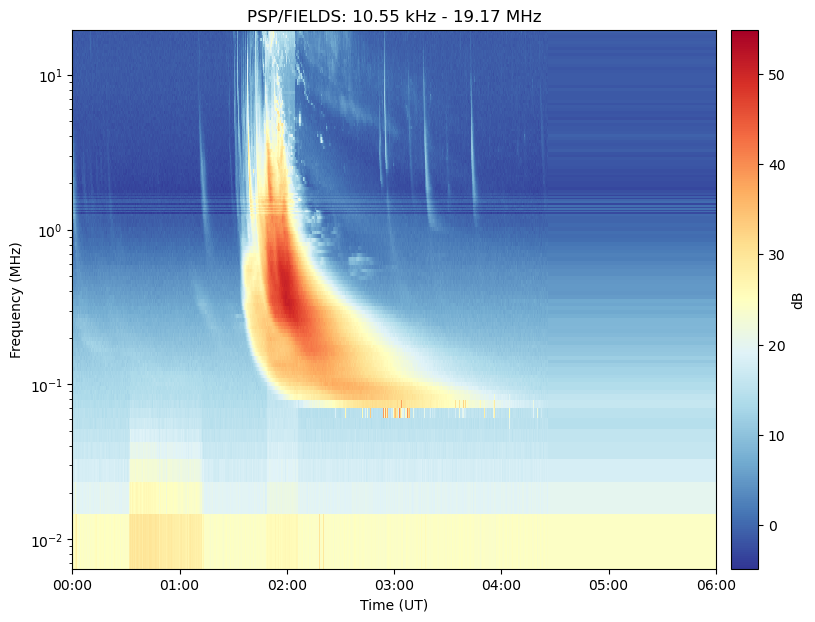

In [211]:
plt.figure(figsize=[10,7])
plt.pcolormesh(tm_hfr, df_psp.index, df_psp,
               shading='auto',
               # vmin=(np.nanmean(df_psp.values)-2 * np.nanstd(df_psp.values)),
               # vmax=(np.nanmean(df_psp.values)+3 * np.nanstd(df_psp.values)),
               cmap='RdYlBu_r')
plt.yscale('log')
plt.xlabel('Time (UT)')
plt.ylabel('Frequency (MHz)')
plt.title(f'PSP/FIELDS: {df_psp.index[0]*1e3:.2f} kHz - {df_psp.index[-1]:.2f} MHz')
plt.gca().xaxis.set_major_formatter(myFmt_time)
plt.xlim(left=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 00:00'),
         right=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 06:00'))
plt.colorbar(pad=0.02, label='dB')
plt.show()

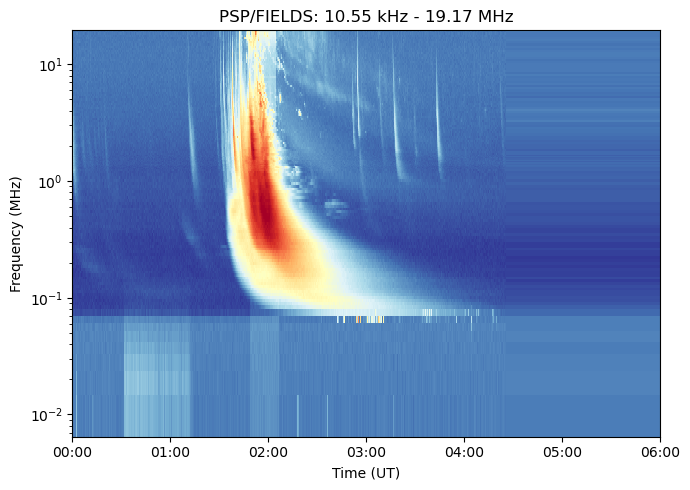

In [225]:
from astropy.visualization import ImageNormalize, PercentileInterval

def minmax_normalize(arr=None):
    """Min-Max normalization"""
    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)
    arr_norm = (arr - min_val) / (max_val - min_val)
    return arr_norm

# calculate the mean value in each row (freq channel)
# and subtract it from each corresponding row
df_psp_mean = df_psp.mean(axis=1)
df_psp_submean = df_psp.sub(df_psp_mean, axis=0)

# rescale the data
psp_submean_norm = minmax_normalize(arr=df_psp_submean)
df_psp_submean_norm = pd.DataFrame(psp_submean_norm, index=df_psp.index, columns=df_psp.columns)
psp_norm = ImageNormalize(df_psp_submean_norm.values, interval=PercentileInterval(99.97), clip=True)

plt.figure(figsize=[7,5])
plt.pcolormesh(tm_hfr, df_psp.index, df_psp_submean_norm,
               norm=psp_norm,
               shading='auto',
               cmap='RdYlBu_r')
plt.yscale('log')
plt.xlabel('Time (UT)')
plt.ylabel('Frequency (MHz)')
plt.title(f'PSP/FIELDS: {df_psp.index[0]*1e3:.2f} kHz - {df_psp.index[-1]:.2f} MHz')
plt.gca().xaxis.set_major_formatter(myFmt_time)
plt.xlim(left=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 00:00'),
         right=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 06:00'))
plt.tight_layout()
plt.show()

<a id="load_solo"></a>
## Load SolO

- [Go to Top](#top)

<a id="load_sta"></a>
## Load STA

- [Go to Top](#top)

In [226]:
# Calibrated STEREO/SWAVES radio dynamic spectra in SFU
try:
    URL = f'https://spdf.gsfc.nasa.gov/pub/data/stereo/ahead/l3/waves/hfr/{YEAR}/sta_l3_wav_hfr_{YEAR}{MONTH}{DAY}_v01.cdf'
    response = requests.get(URL)
    open(f'{basedir}/STEREO/SWAVES/sta_l3_wav_hfr_{YEAR}{MONTH}{DAY}_v01.cdf', 'wb').write(response.content)
    print('Data is fetched sccessfully')
except:
    print('No data is found')

Data is fetched sccessfully


In [227]:
# read the data
cdf_stA  = pycdf.CDF(f'{basedir}/STEREO/SWAVES/sta_l3_wav_hfr_{YEAR}{MONTH}{DAY}_v01.cdf')
time_stA = np.array(cdf_stA.get('Epoch'))
freq_stA = np.array(cdf_stA.get('FREQUENCY'))/1e6 # in MHz
data_stA = np.array(cdf_stA.get('PSD_SFU'))

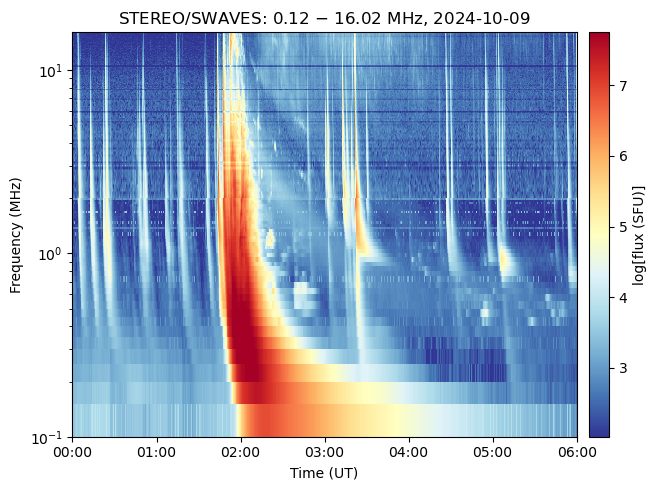

In [232]:
fig, ax = plt.subplots(figsize=[7,5])
dyspec = ax.pcolormesh(time_stA, freq_stA,
                       np.log10(data_stA).T,
                       vmin=np.nanpercentile(np.log10(data_stA).ravel(), 10),
                       vmax=np.nanpercentile(np.log10(data_stA).ravel(), 99.97),
               cmap='RdYlBu_r')
plt.colorbar(dyspec, pad=0.02, label='log[flux (SFU)]')
ax.set_yscale('log')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title(f'STEREO/SWAVES: {freq_stA[0]:.2f} $-$ {freq_stA[-1]:.2f} MHz, {time_stA[0].date()}')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(left=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 00:00'),
         right=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 06:00'))
fig.tight_layout()
plt.show()

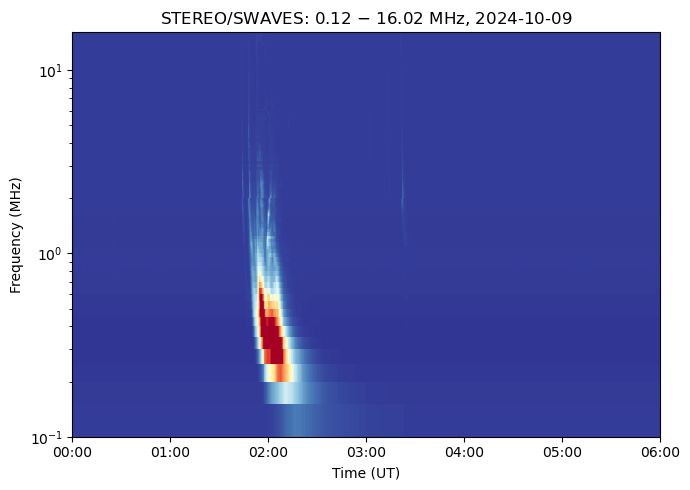

In [243]:
# subtract the Mean value 
# calculate the mean intensity in each row (freq channel) 
df_stA = pd.DataFrame(data_stA.T)
df_stA_mean = df_stA.mean(axis=1)

# subtract that mean value from each corresponding row 
df_stA_meanSub = df_stA.sub(df_stA_mean, axis=0)

stA_norm = ImageNormalize(df_stA_meanSub.values, interval=PercentileInterval(99.97), clip=True)

fig, ax = plt.subplots(figsize=[7,5])
dyspec = ax.pcolormesh(time_stA, freq_stA, df_stA_meanSub,
                       norm=stA_norm, cmap='RdYlBu_r')
ax.set_yscale('log')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title(f'STEREO/SWAVES: {freq_stA[0]:.2f} $-$ {freq_stA[-1]:.2f} MHz, {time_stA[0].date()}')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(left=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 00:00'),
         right=pd.Timestamp(f'{YEAR}-{MONTH}-{DAY} 06:00'))
fig.tight_layout()
plt.show()

In [148]:
# stA_STOKES_I = np.array(cdf_stA.get('STOKES_I'))
# stA_STOKES_Q = np.array(cdf_stA.get('STOKES_Q'))
# stA_STOKES_U = np.array(cdf_stA.get('STOKES_U'))
# stA_STOKES_V = np.array(cdf_stA.get('STOKES_V'))

In [154]:
# fig, ax = plt.subplots(figsize=[12,4])
# dyspec = ax.pcolormesh(time_stA, freq_stA,
#                        stA_STOKES_I.T,
#                        # np.log10(stA_STOKES_I).T,
#                        vmin=np.nanpercentile(np.log10(stA_STOKES_I).ravel(), 10),
#                        vmax=np.nanpercentile(np.log10(stA_STOKES_I).ravel(), 99.97),
#                cmap='seismic')
# plt.colorbar(dyspec, pad=0.01, label='log[flux (SFU)]')
# # ax.set_yscale('log')
# ax.set_xlabel('Time (UT)')
# ax.set_ylabel('Frequency (MHz)')
# ax.set_title(f'STEREO/SWAVES: {freq_stA[0]:.2f} $-$ {freq_stA[-1]:.2f} MHz, {time_stA[0].date()}')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# fig.tight_layout()
# plt.show()

In [155]:
# fig, ax = plt.subplots(figsize=[12,4])
# dyspec = ax.pcolormesh(time_stA, freq_stA,
#                        np.log10(stA_STOKES_Q).T,
#                        vmin=np.nanpercentile(np.log10(stA_STOKES_Q).ravel(), 10),
#                        vmax=np.nanpercentile(np.log10(stA_STOKES_Q).ravel(), 99.97),
#                cmap='seismic')
# plt.colorbar(dyspec, pad=0.01, label='log[flux (SFU)]')
# # ax.set_yscale('log')
# ax.set_xlabel('Time (UT)')
# ax.set_ylabel('Frequency (MHz)')
# ax.set_title(f'STEREO/SWAVES: {freq_stA[0]:.2f} $-$ {freq_stA[-1]:.2f} MHz, {time_stA[0].date()}')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# fig.tight_layout()
# plt.show()

In [156]:
# fig, ax = plt.subplots(figsize=[12,4])
# dyspec = ax.pcolormesh(time_stA, freq_stA,
#                        np.log10(stA_STOKES_U).T,
#                        vmin=np.nanpercentile(np.log10(stA_STOKES_U).ravel(), 10),
#                        vmax=np.nanpercentile(np.log10(stA_STOKES_U).ravel(), 99.97),
#                cmap='seismic')
# plt.colorbar(dyspec, pad=0.01, label='log[flux (SFU)]')
# ax.set_yscale('log')
# ax.set_xlabel('Time (UT)')
# ax.set_ylabel('Frequency (MHz)')
# ax.set_title(f'STEREO/SWAVES: {freq_stA[0]:.2f} $-$ {freq_stA[-1]:.2f} MHz, {time_stA[0].date()}')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# fig.tight_layout()
# plt.show()

In [157]:
# fig, ax = plt.subplots(figsize=[12,4])
# dyspec = ax.pcolormesh(time_stA, freq_stA,
#                        np.log10(stA_STOKES_V).T,
#                        vmin=np.nanpercentile(np.log10(stA_STOKES_V).ravel(), 10),
#                        vmax=np.nanpercentile(np.log10(stA_STOKES_V).ravel(), 99.97),
#                cmap='seismic')
# plt.colorbar(dyspec, pad=0.01, label='log[flux (SFU)]')
# ax.set_yscale('log')
# ax.set_xlabel('Time (UT)')
# ax.set_ylabel('Frequency (MHz)')
# ax.set_title(f'STEREO/SWAVES: {freq_stA[0]:.2f} $-$ {freq_stA[-1]:.2f} MHz, {time_stA[0].date()}')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# fig.tight_layout()
# plt.show()

<a id="load_wind"></a>
## Load Wind

- [Go to Top](#top)

**Thermal Noise Receiver (TNR)**
- Inputs: Ex, Ey, or Ez
- Frequency range: 4 kHz - 256 kHz
- No. channels: 32 or 16 per band (5 bands)
- Bandwidth: 400 Hz - 6.4 kHz
- Sensitivity: 7 nV/sqrt(Hz)

**Radio Receiver Band 1 (RAD1)**
- Inputs: Ex+Ez, Ez
- Frequency range: 20 kHz - 1,040 kHz
- No. channels: 256
- Bandwidth: 3 kHz
- Sensitivity: 7 nV/sqrt(Hz)

**Radio Receiver Band 2 (RAD2)**
- Inputs: Ey+Ez, Ez
- Frequency range: 1.075 MHz - 13.825 MHz
- No. channels: 256
- Bandwidth: 20 kHz
- Sensitivity: 7 nV/sqrt(Hz)

[More info](https://spdf.gsfc.nasa.gov/pub/data/stereo/documents/websites/solar-radio/wind/instrument.html)

In [103]:
# No data is available for 2024-10-09 using my old code ...

In [104]:
# This method works only on L2 data that I downloaded manually
filename = f'{basedir}/WIND/WAVES/wi_wa_rad1_l2_{YEAR}{MONTH}{DAY}_v01.dat'

waves = read_l2_hres(filename)
waves_data, waves_header = waves.data, waves.header

Reading sweep #1
Reading sweep #2
Reading sweep #3
Reading sweep #4
Reading sweep #5
Reading sweep #6
Reading sweep #7
Reading sweep #8
Reading sweep #9
Reading sweep #10
Reading sweep #11
Reading sweep #12
Reading sweep #13
Reading sweep #14
Reading sweep #15
Reading sweep #16
Reading sweep #17
Reading sweep #18
Reading sweep #19
Reading sweep #20
Reading sweep #21
Reading sweep #22
Reading sweep #23
Reading sweep #24
Reading sweep #25
Reading sweep #26
Reading sweep #27
Reading sweep #28
Reading sweep #29
Reading sweep #30
Reading sweep #31
Reading sweep #32
Reading sweep #33
Reading sweep #34
Reading sweep #35
Reading sweep #36
Reading sweep #37
Reading sweep #38
Reading sweep #39
Reading sweep #40
Reading sweep #41
Reading sweep #42
Reading sweep #43
Reading sweep #44
Reading sweep #45
Reading sweep #46
Reading sweep #47
Reading sweep #48
Reading sweep #49
Reading sweep #50
Reading sweep #51
Reading sweep #52
Reading sweep #53
Reading sweep #54
Reading sweep #55
Reading sweep #56
R

In [22]:
waves_data[1].keys()

dict_keys(['FREQ', 'VSPAL', 'VZPAL', 'TSPAL', 'TZPAL'])

In [74]:
dict = {f'{sweep}': [] for sweep in waves_header[0].keys()}

for i in range(len(waves_header)):
    for key in waves_header[i].keys():
        dict[key].append(waves_header[i][key])

df = pd.DataFrame(dict, columns=dict.keys())
mydatetimes = [ f"{df['YEAR'][d]}-{df['MONTH'][d]}-{df['DAY'][d]}T{df['HOUR'][d]}:{df['MINUTE'][d]}:{df['SECOND'][d]}" \
                    for d in range(len(df)) ]
df.index = pd.to_datetime(mydatetimes)

for i in range(len(df)):
    if df['RECEIVER_CODE'][i] == 0:
        df['RECEIVER_CODE'][i] = 'TNR'
    elif df['RECEIVER_CODE'][i] == 1:
        df['RECEIVER_CODE'][i] = 'RAD1'
    elif df['RECEIVER_CODE'][i] == 2:
        df['RECEIVER_CODE'][i] = 'RAD2'
    if df['IUNIT'][i] == 3:
        df['IUNIT'][i] = 'µV^2/Hz'

df.head()

,P_FIELD,JULIAN_DAY_B1,JULIAN_DAY_B2,JULIAN_DAY_B3,MSEC_OF_DAY,RECEIVER_CODE,JULIAN_SEC_FRAC,YEAR,MONTH,DAY,...,IANTEN,IPOLA,IDIPXY,SDURCY,SDURPA,NPALCY,NFRPAL,NPALIF,NSPALF,NZPALF
2024-10-08 23:59:30,76,0,61,5,86370141,RAD1,0.142,2024,10,8,...,2,1,1,183.236725,2.863074,64,1,64,16,8
2024-10-09 00:02:33,76,0,61,6,153406,RAD1,0.406,2024,10,9,...,2,1,1,183.236725,2.863074,64,1,64,16,8
2024-10-09 00:05:36,76,0,61,6,336670,RAD1,0.670,2024,10,9,...,2,1,1,183.236725,2.863074,64,1,64,16,8
2024-10-09 00:08:39,76,0,61,6,519933,RAD1,0.934,2024,10,9,...,2,1,1,183.236725,2.863074,64,1,64,16,8
2024-10-09 00:11:43,76,0,61,6,703197,RAD1,0.198,2024,10,9,...,2,1,1,183.236725,2.863074,64,1,64,16,8


In [128]:
# Extract 'VSPAL' from each dict and convert to array
vspal = np.column_stack([np.array(d['VSPAL']) for d in waves_data])
vspal.shape

(1024, 457)

In [124]:
freq = np.array(waves_data[0]['FREQ'])
freq.shape

(64,)

In [129]:
times = df.index
times.shape

(457,)

In [132]:
dynamic_spectrum = vspal.reshape(457, 64, 16).mean(axis=2).T  # shape: 64 x 457
dynamic_spectrum.shape

(64, 457)

In [158]:
# plt.figure(figsize=(12, 6))
# plt.pcolormesh(times, freq, dynamic_spectrum, shading='auto')
# plt.xlabel('Time index')
# plt.ylabel('Frequency [kHz]')
# plt.colorbar(label='Intensity (arbitrary units)')
# plt.show()

In [166]:
# Another method ...
import pyspedas
from pytplot import tplot
from pytplot import get_data

time_range = [f'{YEAR}-{MONTH}-{DAY}', f'{YEAR}-{MONTH}-{DAY}']
wind_vars = pyspedas.wind.waves(trange=time_range)

RAD2_times, RAD2_int, RAD2_freq = get_data('E_VOLTAGE_RAD2')
RAD1_times, RAD1_int, RAD1_freq = get_data('E_VOLTAGE_RAD1')
TNR_times,  TNR_int,  TNR_freq  = get_data('E_VOLTAGE_TNR')

wind_freq = np.concatenate((TNR_freq, RAD1_freq, RAD2_freq))
wind_data = np.concatenate((TNR_int, RAD1_int, RAD2_int), axis=1)

17-Dec-25 20:42:39: File is current: wind_data/wind_masters/wi_h1_wav_00000000_v01.cdf
17-Dec-25 20:42:39: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/wind/waves/wav_h1/2024/
17-Dec-25 20:42:39: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/wind/waves/wav_h1/2024/
17-Dec-25 20:42:41: The name E_VOLTAGE_RAD2 is currently not in pytplot


TypeError: cannot unpack non-iterable NoneType object

In [167]:
tplot(['E_VOLTAGE_RAD2', 'E_VOLTAGE_RAD1', 'E_VOLTAGE_TNR'])

17-Dec-25 20:42:42: wildcard_expand: empty master list
17-Dec-25 20:42:42: tplot: No matching tplot names were found


In [ ]:
fig = plt.figure(figsize=[10,7])
ax = plt.gca()
ax.imshow(wind_data.T, aspect='auto', origin='lower', 
               #vmin=(np.mean(wind_data)-2 * np.std(RAD2_int)), 
               #vmax=(np.mean(wind_data)+3 * np.std(RAD2_int)), 
               vmin=0.85, vmax=1.4, 
               extent=[dates.date2num(datetime.datetime.strptime(pyspedas.time_string(TNR_times)[0], '%Y-%m-%d %H:%M:%S.%f')), 
                       dates.date2num(datetime.datetime.strptime(pyspedas.time_string(TNR_times)[-1], '%Y-%m-%d %H:%M:%S.%f')), 
                       wind_freq[0]/1e3, wind_freq[-1]/1e3
                      ], cmap='RdBu_r')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title(f'Wind/WAVES: {wind_freq[0]:.2f} kHz - {wind_freq[-1]/1e3:.2f} MHz')
ax.set_xlim(left=pd.Timestamp('2019-04-03 12:15'), right=pd.Timestamp('2019-04-03 12:55'))
plt.show()

<a id="plot"></a>
## Plotting

- [Go to Top](#top)

In [ ]:
fig = plt.figure(figsize=[20,10])
gs  = GridSpec(4, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.pcolormesh(df_psp.columns,
               df_psp.index,
               df_psp.values,
               norm=psp_norm,
               cmap='RdYlBu_r')
ax1.axvline(x=moment, color='k', ls='--', lw=2)
ax1.set_ylabel('Frequency (MHz)')
ax1.set_title(f"PSP/FIELDS: {df_psp.index[0]*1e3:.2f} kHz $-$ {df_psp.index[-1]:.2f} MHz")
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax2 = fig.add_subplot(gs[1, 0])
ax2.pcolormesh(time_ste,
               freq_ste/1e3,
               data_ste_A,
               norm=ste_norm,
               cmap='RdYlBu_r')
ax2.axvline(x=moment, color='k', ls='--', lw=2)
ax2.grid(False)
ax2.set_ylabel('Frequency (MHz)')
ax2.set_title(f"STEREO/SWAVES: {freq_ste[0]:.2f} kHz $-$ {freq_ste[-1]/1e3:.2f} MHz")
ax2.xaxis_date()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax3 = fig.add_subplot(gs[2, 0])
ax3.pcolormesh(wind_time,
               wind_freq/1e3,
               wind_data.T,
               norm=wind_norm,
               cmap='RdYlBu_r')
ax3.axvline(x=moment, color='w', ls='--', lw=2)
ax3.set_ylabel('Frequency (MHz)')
ax3.set_title(f"Wind/WAVES: {wind_freq[0]:.2f} kHz $-$ {wind_freq[-1]/1e3:.2f} MHz")
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax4 = fig.add_subplot(gs[3, 0])
goes.plot(axes=ax4)
ax4.set_xlim(left=mdates.date2num(pd.Timestamp(str(goes.time_range.start))),
             right=mdates.date2num(pd.Timestamp(str(goes.time_range.end))))
ax4.axvline(x=moment, color='k', ls='--', lw=2)
ax4.set_xlabel('Time (UT)')
ax4.set_title(f"{goes.observatory}/{goes.source.upper()}")

ax5 = fig.add_subplot(gs[:, 1], projection=aiamap_normalized)
aiamap_normalized.plot(axes=ax5, vmin=0)
ax5.grid(False)
ax5.set_xlabel('Helioprojective Lonitude (Solar-X)')
ax5.set_ylabel('Helioprojective Latitude (Solar-Y)')

fig.tight_layout()
# fig.savefig(f'./plots/monitor/monitor_plot_{moment}.png', format='png', dpi=300, bbox_inches='tight')
plt.show()